# Prototype: Combine results of calibrations from multiple years of a single location

In [1]:
import io
from collections import defaultdict
from pathlib import Path


import matplotlib as mpl
import matplotlib.ticker
import matplotlib.dates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly
import plotly.express as px
import plotly.graph_objects as go
import scipy.stats

from inframind_proteus.empirical_data import DiseaseTimeSeriesCache
from inframind_proteus.outbreak_dynamics.utils import make_axes_seq, rotate_ax_labels, year_week_to_date


def _make_fig_fpath(figname_with_extension, _location_id) -> Path:
    fpath = Path(f"../../.local/combine_calibration_years/{_location_id}/{figname_with_extension}")
    fpath.parent.mkdir(exist_ok=True, parents=True)
    return fpath


## Load single location all seasons

In [29]:
location_id = "AC"
# use_years = list(range(2018, 2023))  # -()- Probe
use_years = list(range(2010, 2024))  # -()- Full

main_output_dir =  Path("../../outputs/validation_round_calibration")
# main_output_dir = Path("../../.local/mind-runner_local/validation_round_calibration")
# main_output_dir = Path("../../.local/la-berenjena_local/validation_round_calibration")
subdir_fmt = "{location_id}_{year}"

# -------------
# Load all data
# =============
keys_list = list()
data_lists = defaultdict(lambda: list())

observations_sr = (
    DiseaseTimeSeriesCache(Path("../../data/disease/dengue_cases_uf_weekly"))
).get_location(location_id)

for year in use_years:
    out_dir = main_output_dir / subdir_fmt.format(location_id=location_id, year=year)

    if not out_dir.exists():
        print(f"WARNING: Output directory for {year} does not exist: {out_dir}")
        continue

    print(f"Loading from {out_dir}...")
    keys_list.append(year)

    # --- Posterior parameter samples
    df = pd.read_csv(
        out_dir / "stage3_posterior_samples.csv.gz",
        index_col="i_simulation",
    )
    data_lists["param_samples"].append(df)

    # --- Maximum likelihood parameters from stage 1
    series = (
        pd.read_csv(
            out_dir / "stage1_max_ll_params.csv",
            index_col="parameter_name"
        )["value"]
    )
    data_lists["maximum_likelihood"].append(series)

    # --- Case trajectories (summary stats by day only, not full trajectories)
    df = (
        pd.read_csv(
            out_dir / "stage3_case_stats_trajectories.csv",
            index_col="date",
            parse_dates=["date"],
        )
    )
    data_lists["case_stats_trajectories"].append(df)

    # --- Calculated outbreak features
    df = pd.read_csv(
        out_dir / "outbreak_feature_stats.csv.gz",
        index_col=0, header=[0, 1], skiprows=[2]
    )
    df.index.name = "i_simulation"
    data_lists["outbreak_features"].append(df)


# Concatenate datasets
# ----------
if len(keys_list) == 0:
    raise ValueError("No data loaded. Check the output directories.")

# --- Posterior samples
param_samples_df = pd.concat(
    data_lists["param_samples"],  # List of dataframes
    axis=0,
    keys=keys_list,  # Use years as keys for the multi-index
    names=["year"],
)

# --- Max likelihood param (list of series into dataframe)
max_likelihood_df = pd.concat(
    data_lists["maximum_likelihood"],  # List of series
    axis=1,
).T
max_likelihood_df.index = use_years
max_likelihood_df.index.name = "year"

# --- Case trajectories (summary stats by day only, not full trjaectories)
case_stats_trajectories_df = pd.concat(
    data_lists["case_stats_trajectories"],
    keys=keys_list,
    names=["year"]
)

# --- Outbreak features
outbreak_features_df = pd.concat(
    data_lists["outbreak_features"],
    axis=0,
    keys=keys_list,
    names=["year"],
)

max_likelihood_df
param_samples_df
outbreak_features_df


Loading from ../../outputs/validation_round_calibration/AC_2010...
Loading from ../../outputs/validation_round_calibration/AC_2011...
Loading from ../../outputs/validation_round_calibration/AC_2012...
Loading from ../../outputs/validation_round_calibration/AC_2013...
Loading from ../../outputs/validation_round_calibration/AC_2014...
Loading from ../../outputs/validation_round_calibration/AC_2015...
Loading from ../../outputs/validation_round_calibration/AC_2016...
Loading from ../../outputs/validation_round_calibration/AC_2017...
Loading from ../../outputs/validation_round_calibration/AC_2018...
Loading from ../../outputs/validation_round_calibration/AC_2019...
Loading from ../../outputs/validation_round_calibration/AC_2020...
Loading from ../../outputs/validation_round_calibration/AC_2021...
Loading from ../../outputs/validation_round_calibration/AC_2022...
Loading from ../../outputs/validation_round_calibration/AC_2023...


feature           case_attack_rate                                     \
stat                          mean          std       q025       q975   
year i_simulation                                                       
2010 3220                 27576.40  2407.937166  23453.450  32499.075   
     140253               28372.69  1795.835703  25292.475  31761.600   
     5381                 27932.05  1395.328392  25370.650  30583.600   
     6165                 27361.54  8249.632799  14707.400  46800.150   
     6348                 27747.98  1913.908054  24006.800  31508.100   
...                            ...          ...        ...        ...   
2023 211652                9042.56   467.104888   8292.950  10120.750   
     21145                 9450.64   502.702465   8609.775  10493.275   
     261224                9233.12   410.312428   8549.900  10051.500   
     259205                9503.26   536.936195   8521.675  10527.575   
     86153                 9039.38   464.191940   8293.550   9965.975   

feature           peak_week                          peak_amplitude  \
stat                   mean       std   q025    q975           mean   
year i_simulation                                                     
2010 3220             12.65  2.528125  8.475  17.000        2559.46   
     140253           12.55  2.230980  9.000  17.000        2517.56   
     5381             12.73  2.182830  9.000  16.525        2453.42   
     6165             12.78  4.172009  5.475  21.525        6603.26   
     6348             12.35  2.297891  8.475  17.000        2518.44   
...                     ...       ...    ...     ...            ...   
2023 211652            9.77  1.662753  6.000  12.525         792.88   
     21145             9.77  1.625895  7.000  13.000         858.43   
     261224           10.15  1.552938  7.000  13.000         792.26   
     259205            9.95  1.719614  7.000  13.525         865.50   
     86153             9.76  1.658282  6.475  13.000         805.28   

feature                                              
stat                       std      q025       q975  
year i_simulation                                    
2010 3220           518.595645  1774.425   3650.250  
     140253         434.833727  1848.100   3444.700  
     5381           318.035167  1971.850   3128.425  
     6165          3337.658520  2340.750  15203.950  
     6348           406.085061  1854.950   3440.950  
...                        ...       ...        ...  
2023 211652         110.725640   633.375   1043.100  
     21145          134.470473   662.000   1194.925  
     261224          97.758992   611.700    966.975  
     259205         121.084285   666.225   1086.225  
     86153          115.644010   622.900   1048.725  

[61188 rows x 12 columns]

## Process data

,case_attack_rate,peak_week,peak_amplitude
year,,,
2010,28127,12.0,2139
2011,1855,12.0,116
2012,3487,15.0,218
2013,13378,51.0,2068
2014,20887,1.0,1917
2015,2308,16.0,228
2016,1445,15.0,85
2017,3850,51.0,167
2018,9369,4.0,487


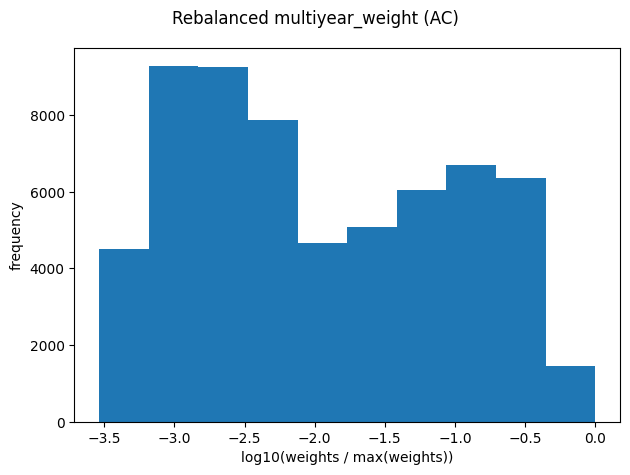

In [30]:
from inframind_proteus.outbreak_dynamics.outbreak_features import outbreak_features_from_trajectories

# Rebalance weights for between-years equality
# ============================================
# Modifies param_samples_df in place by adding a column
df = param_samples_df

_year_index = df.index.get_level_values("year")
sum_weights = df.groupby("year")["posterior_weight"].sum().reindex(_year_index)
sum_weights.index = df.index
df["multiyear_weight"] = df["posterior_weight"] / sum_weights  # Rebalance by year
df["multiyear_weight"] /= df["multiyear_weight"].max()  # Normalize to max = 1


# --- Visualize distribution (relative to maximum)
fig, ax = plt.subplots()
ax.hist(np.log10(df["multiyear_weight"] / df["multiyear_weight"].max()))
ax.set_xlabel("log10(weights / max(weights))")
ax.set_ylabel("frequency")
fig.suptitle(f"Rebalanced multiyear_weight ({location_id})")
fig.tight_layout()

# Prepare a full data frame with all relevant variables
# =================================

exclude_vars = [
    "notif_scaling_factor",  # Placeholder, real scaling is `notif_relative_scale`
]

# --- Merge fixed parameters from stage 1
# (Take only parameters that were not explored)
_new_params = [
    p for p in max_likelihood_df.columns
    if p not in param_samples_df.columns
    and p not in exclude_vars
]
df = pd.merge(
    left=param_samples_df.reset_index(),
    right=max_likelihood_df[_new_params],
    on="year",
).set_index(["year", "i_simulation"])


# --- Merge with outbreak features
# ONLY MEAN to simplify column indexing and plotting
mean_outbreak_features = outbreak_features_df.xs("mean", level="stat", axis=1)
df = pd.merge(
    left=df,
    right=mean_outbreak_features,
    left_index=True, right_index=True,
)


multiyear_samples_df = df


# Outbreak features from the observed data
# =================
calculation_start_epiweek = 41
calculation_end_epiweek = 40  # To calculate from observation data
zero_date_epiweek = 41
# ---
years = outbreak_features_df.index.get_level_values("year").unique()

df_list = list()
for year in years:
    window_start = year_week_to_date(year, calculation_start_epiweek)
    window_end = year_week_to_date(year + 1, calculation_end_epiweek)
    zero_date = year_week_to_date(year, zero_date_epiweek)
    # obs = observations_sr[start_date:end_date]

    obs_features = outbreak_features_from_trajectories(
        pd.DataFrame(observations_sr).T,
        window_start=window_start,
        window_end=window_end,
        zero_date=zero_date,
        feature_names=list(outbreak_features_df.columns.get_level_values("feature").unique()),
    )
    df_list.append(obs_features)

obs_outbreak_features_df = pd.concat(
    df_list,
    ignore_index=True,
)
obs_outbreak_features_df.index = years
obs_outbreak_features_df.index.name = "year"

obs_outbreak_features_df


## Overall visualizations

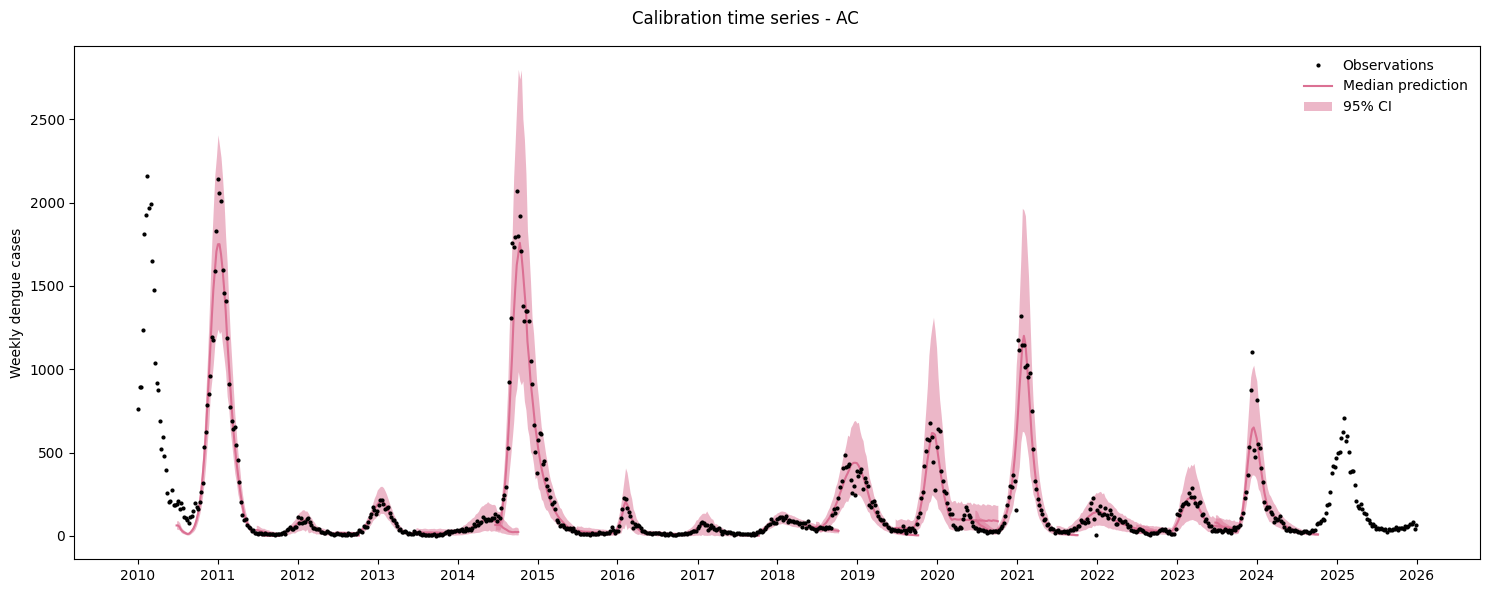

In [31]:
# Plot calibrated trajectories within
# ===================================
case_stats_trajectories_df

# ==== Plot year-wise. Should define a window.

with plt.rc_context({
        "patch.linewidth": 0,
}):
    fig, ax = plt.subplots(figsize=(15, 6))

    # Prediction stats from each year's calibration
    # --------
    for year, df in case_stats_trajectories_df.groupby("year"):
        dates = df.index.get_level_values("date")
        color = "palevioletred"

        pred_ci = ax.fill_between(
            dates, df["q025"], df["q975"],
            alpha=0.5, color=color, label="95% CI"
        )
        pred_med = ax.plot(
            dates, df["median"], color=color, label="Median prediction"
        )[0]

    # --- Observations
    obs = ax.plot(
        observations_sr, "ko", ms=2, label="Observations"
    )[0]

    ax.xaxis.set_major_locator(mpl.dates.YearLocator())
    ax.set_ylabel("Weekly dengue cases")

    ax.legend(handles=[obs, pred_med, pred_ci])
    fig.suptitle(f"Calibration time series - {location_id}")
    fig.tight_layout()
    display(fig)

    fig.savefig(
        _make_fig_fpath(f"calibration_trajectories_{location_id}.pdf", location_id)
    )
    # fpath = Path(f"../../.local/combine_calibration_years/{location_id}/calibration_trajectories_{location_id}.pdf")
    # fpath.parent.mkdir(exist_ok=True, parents=True)
    # fig.savefig(fpath)

    plt.close(fig)

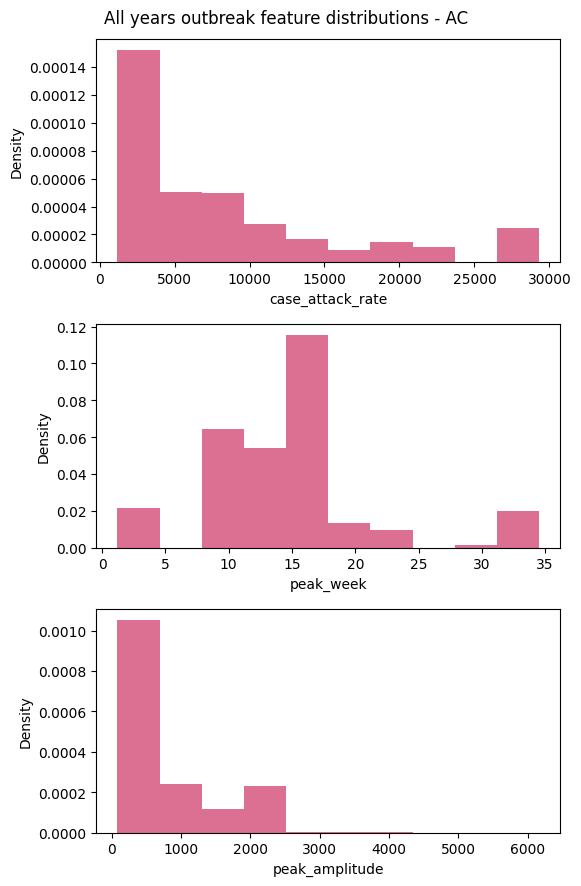

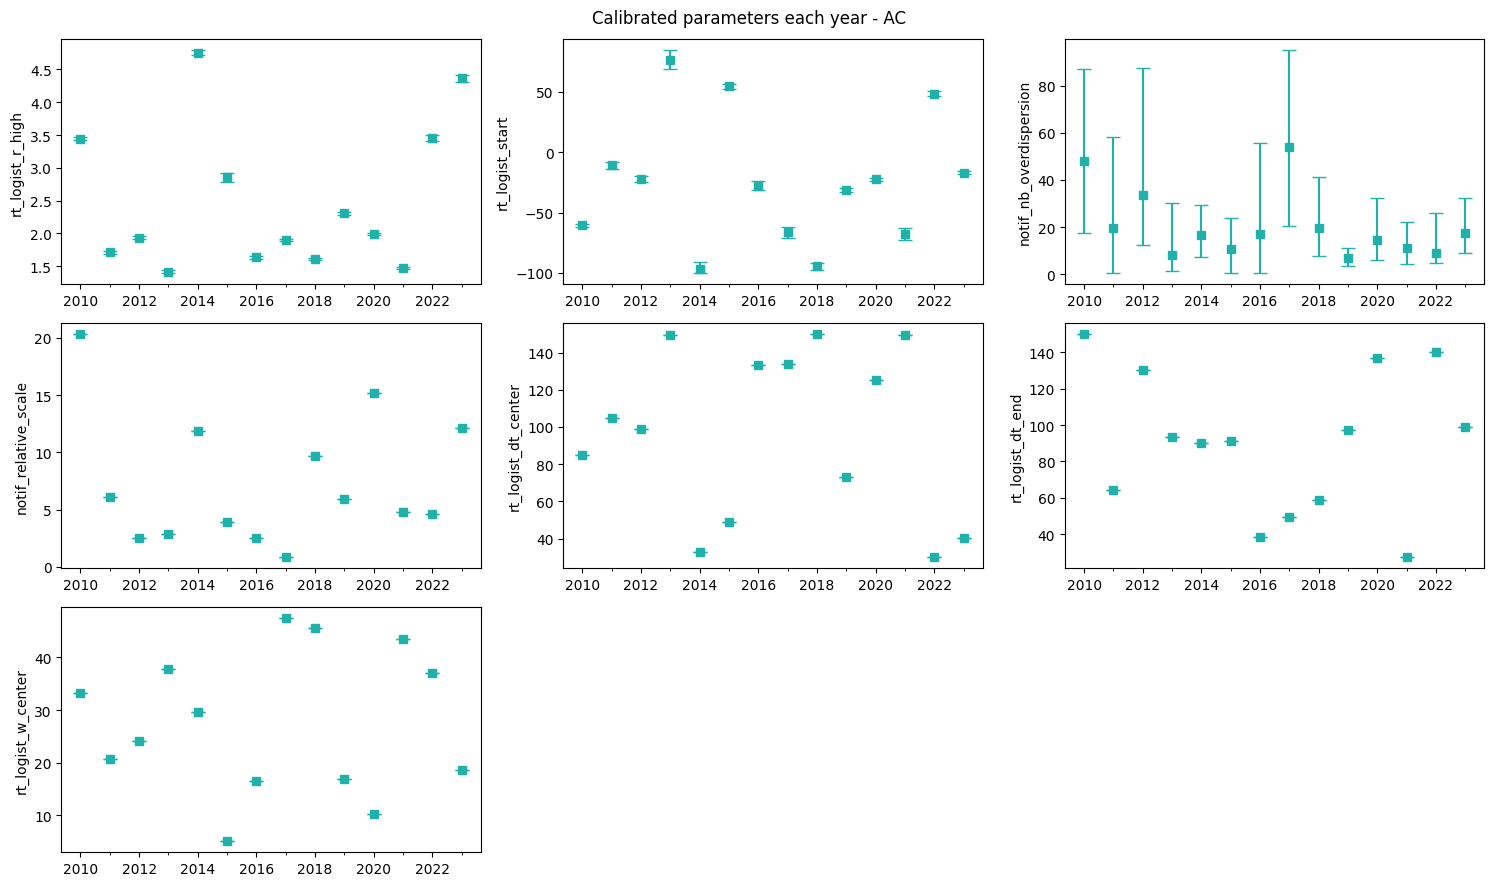

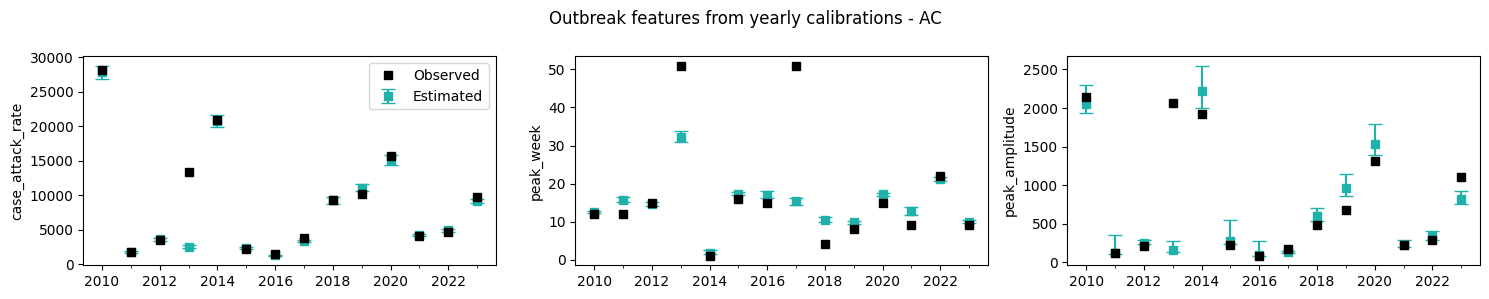

In [32]:
# Subsample from multiyear distribution to enable some calculations.
# =============
# OBS: Replace weights by choices.

n_multiyear_subsamples = 10000
_seed = 151
# ---------
multiyear_subsample_df = multiyear_samples_df.sample(
    n=n_multiyear_subsamples,
    replace=True,
    weights=multiyear_samples_df["multiyear_weight"],
    random_state=_seed,
)

# multiyear_subsample_df.reset_index()["year"].value_counts()  # Yep, pretty uniform on years
multiyear_subsample_df


# Visualize outbreak features (entire sample)
# ===================
feature_names = list(outbreak_features_df.columns.get_level_values("feature").unique())

with plt.rc_context({

}):
    fig, axes = plt.subplots(nrows=len(feature_names), figsize=(6, 3 * len(feature_names)))

    df = multiyear_subsample_df

    for i_feature, feature_name in enumerate(feature_names):
        ax = axes[i_feature]

        ax.hist(df[feature_name], density=True, color="palevioletred")

        ax.set_xlabel(feature_name)
        ax.set_ylabel("Density")

    fig.suptitle(f"All years outbreak feature distributions - {location_id}")
    fig.tight_layout()

    fpath = _make_fig_fpath(f"outbreak_features_{location_id}.pdf", location_id)
    fig.savefig(fpath)
    display(fig)
    plt.close(fig)


# Visualize yearly features and parameters
# ========================================
param_names = [
    "rt_logist_r_high", "rt_logist_start", "notif_nb_overdispersion", # Main parameters
    "notif_relative_scale",
    "rt_logist_dt_center", "rt_logist_dt_end", "rt_logist_w_center",
]
agg_func_list = [
    "mean", "median",
    pd.NamedAgg(column="q025", aggfunc=lambda s: s.quantile(0.025)),
    pd.NamedAgg(column="q975", aggfunc=lambda s: s.quantile(0.975)),
]

# ----------
# Prepare the data frame
df = (
    multiyear_subsample_df
    .groupby("year")
    [param_names]
    .agg({name: agg_func_list for name in param_names})
)
# 2-level column
df.columns.names = ["parameter", "stat"]

feat_stats_df = df

with plt.rc_context({
        "errorbar.capsize": 5,
}):
    fig, axes = make_axes_seq(
        num_axes=len(param_names),
        total_width=15.,
        ax_height=3.,
    )

    for i, param_name in enumerate(param_names):
        ax: plt.Axes = axes[i]

        df = feat_stats_df.xs(param_name, level="parameter", axis=1)
        yerr = [
            df["median"] - df["q025"],
            df["q975"] - df["median"],
        ]

        ax.errorbar(
            x=df.index,
            y=df["median"],
            fmt="s", color="lightseagreen",
            yerr=yerr
        )

        ax.set_ylabel(param_name)
        ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(2))
        ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(1))

    fig.suptitle(f"Calibrated parameters each year - {location_id}")
    fig.tight_layout()

    fig.savefig(
        _make_fig_fpath(f"calibrated_params_yearly_{location_id}.pdf", location_id)
    )
    display(fig)
    plt.close(fig)


# Visualize outbreak features and compare with data
# =================================================

param_names = list(outbreak_features_df.columns.get_level_values("feature").unique())
# Prepare the data frame
df = (
    multiyear_subsample_df
    .groupby("year")
    [param_names]
    .agg({name: agg_func_list for name in param_names})
)
# 2-level column
df.columns.names = ["parameter", "stat"]

feat_stats_df = df

with plt.rc_context({
        "errorbar.capsize": 5,
}):
    fig, axes = make_axes_seq(
        num_axes=len(param_names),
        total_width=15.,
        ax_height=3.,
    )

    for i, param_name in enumerate(param_names):
        ax: plt.Axes = axes[i]

        # --- Plot estimates as error bars
        df = feat_stats_df.xs(param_name, level="parameter", axis=1)
        yerr = [
            df["median"] - df["q025"],
            df["q975"] - df["median"],
        ]
        ax.errorbar(
            x=df.index,
            y=df["median"],
            fmt="s", color="lightseagreen",
            yerr=yerr,
            zorder=10,
            label="Estimated"
        )

        # --- Plot observed values
        df = obs_outbreak_features_df
        ax.plot(
            df[param_name],
            "ks",
            zorder=20,
            label="Observed",
        )

        ax.set_ylabel(param_name)
        ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(2))
        ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(1))

    axes[0].legend()
    fig.suptitle(f"Outbreak features from yearly calibrations - {location_id}")
    fig.tight_layout()

    fig.savefig(
        _make_fig_fpath(f"outbreak_features_yearly_{location_id}.pdf", location_id)
    )
    display(fig)
    plt.close(fig)

In [12]:
# # DEPRECATED (unweighted statistics)
# # ===================
#
# df = multiyear_samples_df
#
# # Yearly calibration aspects
# # ===========================
#
# # For ensemble plots, it's best to sub-sample with weights (e.g. boxplots don't accept weighted calculations)
# # ---
#
# df = df.reset_index()
#
# #
# # param_name = "rt_logist_r_high"
# param_names = [
#     "rt_logist_r_high", "rt_logist_start", "notif_nb_overdispersion", # Main parameters
#     "rt_logist_dt_center", "rt_logist_dt_end", "rt_logist_w_center",
# ]
#
# from plotly.subplots import make_subplots
#
# fig = make_subplots(
#     rows=len(param_names),
#     cols=1,
#     # shared_xaxes=True,
#     vertical_spacing=0.05,
#     # subplot_titles=param_names,
# )
#
# for i_param, param_name in enumerate(param_names):
#     fig.add_box(
#         x=df["year"],
#         y=df[param_name],  # PROBLEM: Unweighted
#         # y=df.groupby("year").apply(
#         #     lambda x: _precompute_weighted_boxplot_arrays(
#         #         pd.DataFrame({"values": x, "weight": df.loc[x.index, "multiyear_weight"]}),
#         #         weight_col="multiyear_weight",
#         #         value_col=param_name,
#         #     )
#         # ),
#         name=param_name,
#         row=i_param + 1, col=1,
#     )
#
#     # fig.update_xaxes(
#     #     title_text="Year" if i_param == len(param_names) - 1 else "",
#     #     row=i_param + 1, col=1,
#     # )
#     fig.update_yaxes(
#         title_text=param_name,
#         row=i_param + 1, col=1,
#     )
#
#     # fig.update_layout(
#     #     row=i_param + 1, col=1,
#     # )
#
#
#
# fig.update_layout(
#     title=f"Yearly calibration parameter distributions ({location_id})",
#     height=300 * len(param_names), width=800,
#     showlegend=False,
#     # boxmode="group"
# )
#
# # ---
# out_fpath = Path(f"../../.local/combine_calibration_years/params_{location_id}.html")
# out_fpath.parent.mkdir(exist_ok=True, parents=True)
# fig.write_html(out_fpath)
# display(fig)